# Triplets pre-processing pipeline

This notebook is used for normalization on triplets produced by the triplets extraction pipeline.

Adjust the path to file(s) containing triplets:

In [1]:
filepath = "../artifacts/raw_triplets/"

files = [# Category_name, file_name
    ("core_clinical", "core_clinical_numsamples200_start0.csv"),
    ("basic_biology", "basic_biology_numsamples200_start0.csv"),
    ("pharmacology", "pharmacology_numsamples200_start0.csv"),
    ("psychiatry", "psychiatry_numsamples200_start0.csv")
]

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

Load and perform basic cleaning on data:

In [3]:
# Read triplets from files and perform basic normalization

k = 2  # minimum length threshold for strings (less than this is meaningless)

clean_dfs = {
    ctg: (
        pd.read_csv(
            os.path.join(filepath, filename),
            on_bad_lines='skip',
            encoding='utf-8',
            encoding_errors='ignore',
            names=['Subject', 'Predicate', 'Object']
        )
        .astype(str)
        # Basic normalization
        .apply(lambda col: (
            col.str.strip()
               .str.lower()
               #replace - with _
               .str.replace('-', '_')
               # Keep only alphabets and specials _.+-
               .str.replace(r"[^a-z_.+-]+", "", regex=True)
               # Collapse dots
               .str.replace(r"\.+", ".", regex=True)
               # Remove leading and trailing . and _
               .str.strip(".")
               .str.strip("_")
        ))
        # Normalize relations: remove underscore in Predicate
        .pipe(lambda df: df.assign(
            Predicate=df['Predicate'].str.replace("_", "", regex=False).str.replace(" ", "", regex=False)
        ))
        # Convert empty strings to NA
        .replace("", pd.NA)
        # Drop rows with missing values
        .dropna(subset=['Subject', 'Predicate', 'Object'])
        # Filter out short / meaningless tokens
        .loc[lambda df: (
            df['Subject'].str.len().ge(k) &
            df['Predicate'].str.len().ge(k) &
            df['Object'].str.len().ge(k)
        )]
        # Drop duplicate triplets
        .drop_duplicates(subset=['Subject', 'Predicate', 'Object'])
        .reset_index(drop=True)
    )
    for ctg, filename in files
}

In [4]:
for ctg, df in clean_dfs.items():
    print(f"Category: {ctg} Number of rows: {df.shape[0]}")

Category: core_clinical Number of rows: 2984
Category: basic_biology Number of rows: 1903
Category: pharmacology Number of rows: 1879
Category: psychiatry Number of rows: 1715


Plot the frequency of each occurence count:

In [5]:
def plot_freq_of_freq(data: pd.DataFrame, ax: plt.Axes, title: str):
    """
    Plot frequency-of-frequency bar chart
    """
    
    # Count the occurence of each entity
    entity_counts = data[['Subject', 'Object']].stack().value_counts()

    # Frequency of each occurence count
    freq_of_freq = entity_counts.value_counts().sort_index()

    # Make x-axis values
    full_index = np.arange(1, entity_counts.max() + 1) 
    freq_of_freq = freq_of_freq.reindex(full_index, fill_value=0)

    # Plot 
    ax.bar(freq_of_freq.index, freq_of_freq.values)
    ax.set_yscale('log')

    ax.set_xlabel("Entity occurrence count (x)")
    ax.set_ylabel("Number of nodes with count x")
    ax.set_title(title)

    return ax

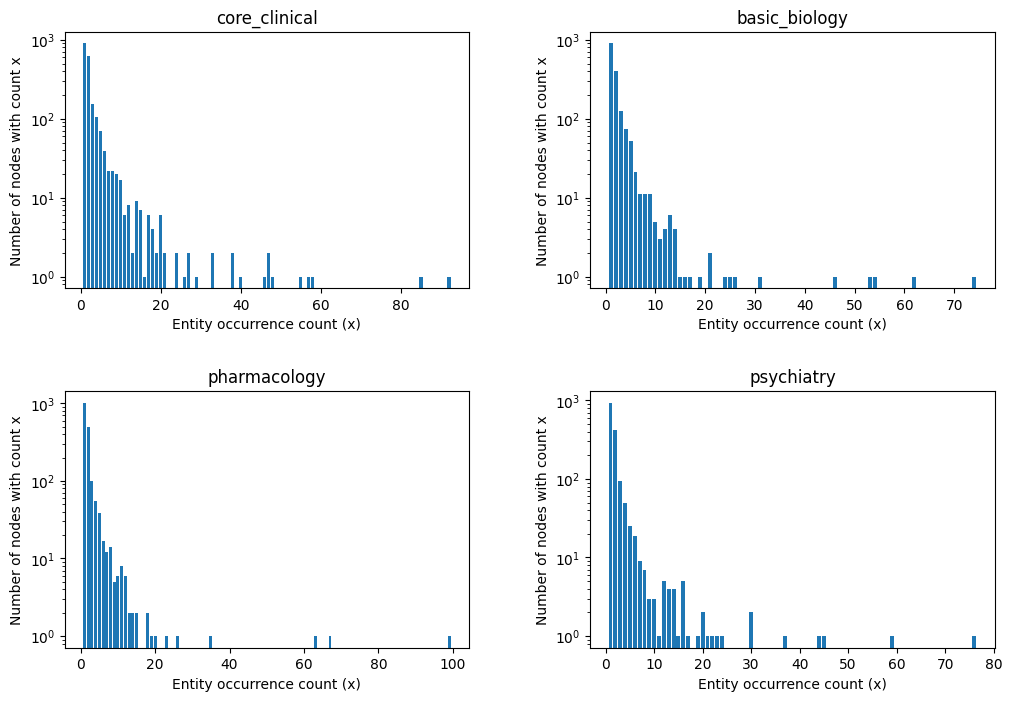

In [6]:
# Plot freq-of-freq of normalized data

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8), )

for i, (ctg, df) in enumerate(clean_dfs.items()):
    plot_freq_of_freq(df, axs[i // 2, i % 2], ctg)


fig.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

Perform pruning to remove rare entities, stabilizing the data:

In [7]:
def prune_entities(data: pd.DataFrame, min_count=2):
    """
    Perform k-core pruning to remove rare entities
    """
    
    df = data.copy()

    while True:
        # Collect all entities in triplets
        counts = df[['Subject', 'Object']].stack().value_counts()

        # Get entities with >= number of occurences
        valid_entities = counts[counts >= min_count].index

        # Make mask
        new_df = df[
            df['Subject'].isin(valid_entities) &
            df['Object'].isin(valid_entities)
        ]

        # Stop when the dataframe is stable
        if len(new_df) == len(df):
            break
        df = new_df

    return df


trim_dfs = {
    ctg : prune_entities(df, min_count=2) for ctg, df in clean_dfs.items()
}

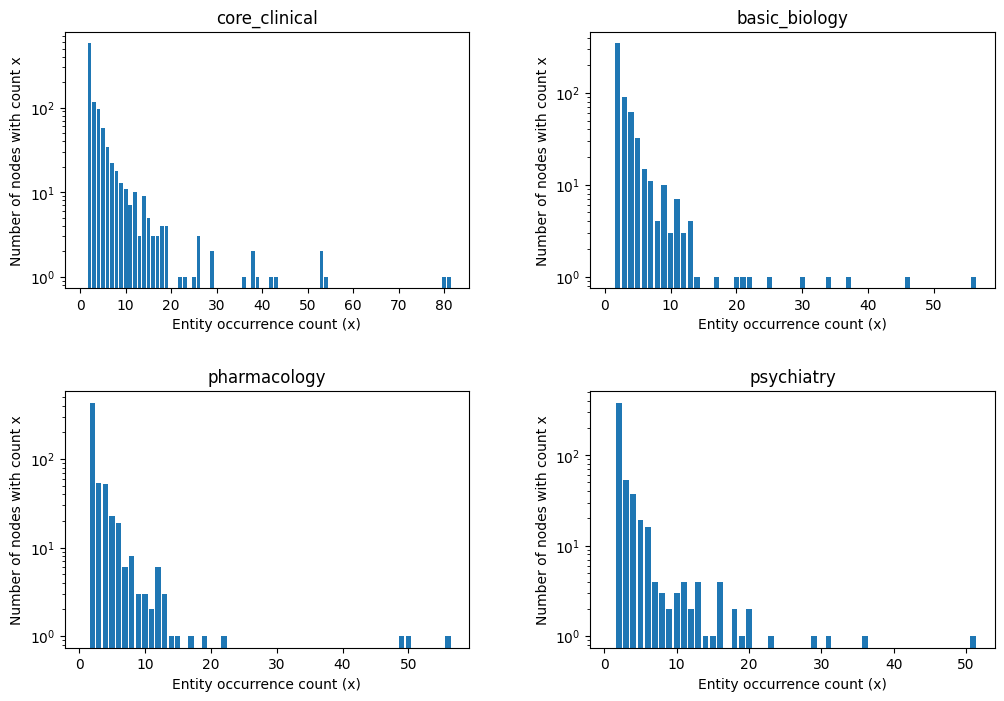

In [8]:
# Plot freq-of-freq of pruned data

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8), )

for i, (ctg, df) in enumerate(trim_dfs.items()):
    plot_freq_of_freq(df, axs[i // 2, i % 2], ctg)


fig.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

In [9]:
# Concatenate all dataframes into a single list for the final graph data
large_df = pd.concat(list(trim_dfs.values()))
large_df

,Subject,Predicate,Object
0,structures,partof,anatomy
4,anatomy,studies,structures
5,anatomy,practices,studying
8,gross_anatomy,isa,studied_anatomy
9,studied_anatomy,haspart,gross_anatomy
...,...,...,...
1709,intellectual_disability,isdifferentfrom,autism_spectrum_disorder
1710,autismspectrumdisorder,isdifferentfrom,social_pragmatic
1711,autism_spectrum_disorder,isdifferentfrom,intellectual_disability
1713,intellectual_disability,isdifferentfrom,appropriate_diagnosis


In [10]:
large_df = large_df.apply(
    lambda col: (
        col.str.replace("_+", " ", regex=True)  # collapse multiple underscores → single space
           .str.strip()                         # remove leading/trailing spaces
           .str.replace(r"\s+", " ", regex=True)  # collapse multiple spaces → one
    )
)

In [11]:
os.makedirs("../artifacts/graph_triplets", exist_ok=True)
large_df.to_csv("../artifacts/graph_triplets/graph_edges.csv", header=False, index=False)